# Clase Práctica SciKit-Fuzzy

## Ejemplo 1: Propina

Ud. acude al restaurant **El maestro difuso**, el rey de la comida univesitaria cercano a la **Universidad Difusa Federico Santa María**. Ud. como buen comensal, desea dejar propina, pero su decisión estará basada en la calidad de la comida y la atención del mesero: Si las cosas van mal, no dejará propina y si van de forma inigualable dejará hasta 15%, vale decir, añadirá hasta un 5% extra al 10% sugerido. El resto variará entre una fracción del 10% base y el sugerido normalmente.

Ahora, considerando el común nacional, las evaluaciones se hacen en una escala del 1 al 7 con décimas. Sin embargo, ud. define sus escala subjetivas de la siguientes formas ascendentes:
* Comida: `pesimo`, `malito`, `piola`, `de pana`, `basadísimo`.
* Atención: `amarga`, `pesada`, `noesni`, `tela`, `joya`.
Además, no tiene claro que valor de la escala representa cada una de sus calificaciones. 

**Construya un sistema de lógica difusa que le permita resolver cuanta propina debiese dejar según la probable atención en el restaurant**. Defina claramente variables numéricas, difusas, funciones de pertenencia, reglas difusas. Además explique, ¿Cuándo ocurre la Fuzzificación y la Defuzzificación?

### Variables de Entradas:
* ¿Qué tan bueno estuvo el almuerzo?:
    * Variable: `comida`.
    * Como variable numérica, universo: $\{1.0, 1.1, 1.2, 1.3,\dots,6.7, 6.8, 6.9, 7.0\}$
    * Como variable difusa: $\{\texttt{pesimo}, \texttt{ malito}, \texttt{ piola}, \texttt{ de pana}, \texttt{ basadísimo}\}$

* ¿Qué tan bien te atendieron?:
    * Variable: `atención`.
    * Como variable numérica, universo: $\{1.0, 1.1, 1.2, 1.3,\dots,6.7, 6.8, 6.9, 7.0\}$
    * Como variable difusa: $\{\texttt{amarga}, \texttt{ pesada}, \texttt{ noesni}, \texttt{ tela}, \texttt{ joya}\}$

### Variables de Salida
* ¿Cuánta propina voy a dejar?
    * Variable: `propina`
    * Como variable numérica, universo (en %): $\{0, 1, 2, 3, \dots, 9, 10, 11, 12, 13, 14, 15\}$
    * Como variable difusa: $\{\texttt{nada}, \texttt{ poco}, \texttt{ normal}, \texttt{ extra}\}$

In [1]:
# Incluir librerías
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [2]:
# Variable de Entrada
calidad = ctrl.Antecedent(np.arange(1, 7.1, 0.1), 'calidad') #pésimo, malito, mas o menos, bueno, excelente
atención = ctrl.Antecedent(np.arange(1, 7.1, 0.1), 'atención') #antipatica, apatica, normal, empatico, atentísimo

#Variable de salida
propina = ctrl.Consequent(np.arange(0, 15.1, 0.1), 'propina')

#.universe es un Antecedent que tiene todos los valores que puede tomar la variable numérica
print(propina.universe) 

[ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10.  10.1 10.2 10.3 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1
 11.2 11.3 11.4 11.5 11.6 11.7 11.8 11.9 12.  12.1 12.2 12.3 12.4 12.5
 12.6 12.7 12.8 12.9 13.  13.1 13.2 13.3 13.4 13.5 13.6 13.7 13.8 13.9
 14.  14.1 14.2 14.3 14.4 14.5 14.6 14.7 14.8 14.9 15. ]


/home/polivares/mambaforge/envs/IPD434/lib/python3.11/site-packages/skfuzzy/control/fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


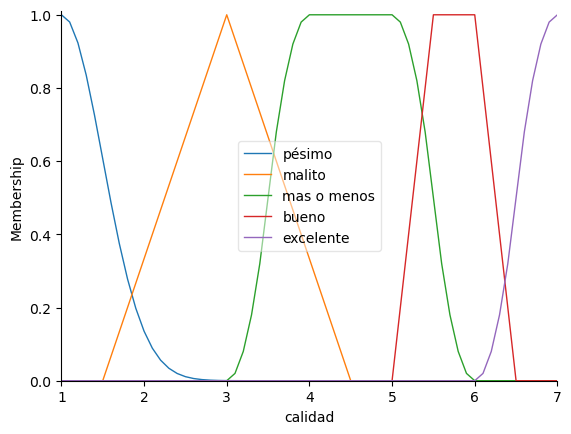

In [3]:
# Definir funciones de pertenencia
# Cada valor de la variable difusa debe tener una función de pertenencia
# funciones de referencia en: https://pythonhosted.org/scikit-fuzzy/api/skfuzzy.membership.html
calidad['pésimo'] = fuzz.gaussmf(calidad.universe, 1,0.5)
calidad['malito'] = fuzz.trimf(calidad.universe,[1.5,3,4.5])
calidad['mas o menos'] = fuzz.pimf(calidad.universe, 3,4,5,6)
calidad['bueno'] = fuzz.trapmf(calidad.universe,[5,5.5,6.0,6.5])
calidad['excelente'] = fuzz.smf(calidad.universe,6.0,7)

#graficar pertenencias ['categoria'] para graficar una sola pertenencia, i.e., calidad['pesimo'].view()
#calidad['pésimo'].view()
calidad.view()

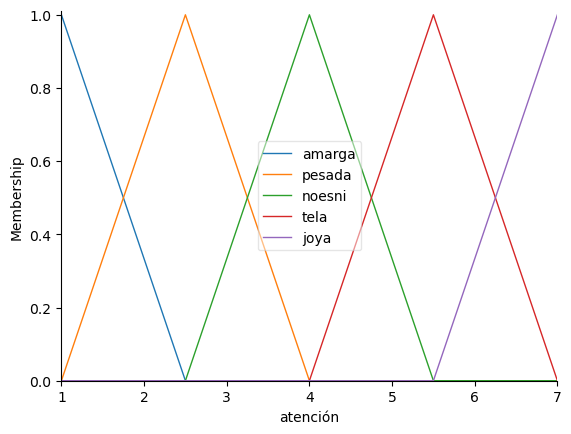

In [4]:
# Existe un método de generación automática de función de membresía triangular
# Funciona solo colo los valores 3, 5, o 7.
# Para otra cantidad de categorías, se debe hacer manualmente o pasar una lista con n labels 
nombres = ["amarga", "pesada", "noesni", "tela", "joya"]
atención.automf(names=nombres)
atención.view()

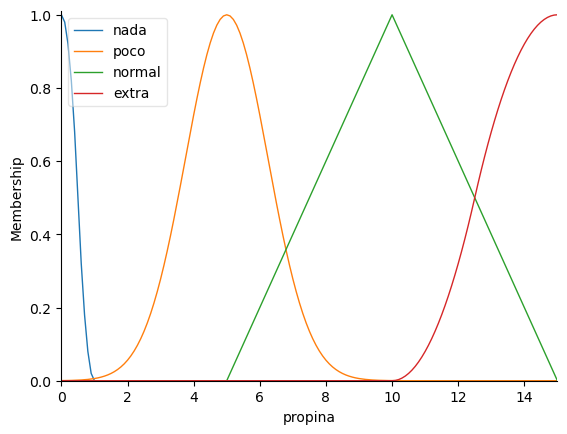

In [5]:
salida=["nada", "poco", "normal", "extra"]
propina.automf(names=salida) #comenzamos con automático
propina["nada"]=fuzz.zmf(propina.universe,0,1)
propina["poco"]=fuzz.gaussmf(propina.universe, 5, 1.25)
propina["extra"]=fuzz.smf(propina.universe,10,15)
propina.view()

    Rules

            IF the service was good or the food quality was good, THEN the tip will be high.

            IF the service was average, THEN the tip will be medium.

            IF the service was poor and the food quality was poor THEN the tip will be low.

    Usage

            If I tell this controller that I rated:

                    the service as 9.8, and

                    the quality as 6.5,

            it would recommend I leave:

                    a 20.2% tip.
